In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [3]:
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 中英文兼容

In [4]:
# 读取三个 .npy 文件
normal_file = 'normal-0.npy'
label_poison_file = 'UnPro_label-32.npy'
feature_poison_file = 'UnPro_feature-32.npy'
P_label_poison_file = 'label-32.npy'
P_feature_poison_file = 'feature-32.npy'

In [5]:
normal = np.load(normal_file)
label_poison = np.load(label_poison_file)
feature_poison = np.load(feature_poison_file)
P_label_poison = np.load(P_label_poison_file)
P_feature_poison = np.load(P_feature_poison_file)

In [6]:
# 确保数据是一维的
assert normal.ndim == 1, "数据应为一维数组"
assert label_poison.ndim == 1, "数据应为一维数组"
assert feature_poison.ndim == 1, "数据应为一维数组"
assert P_label_poison.ndim == 1, "数据应为一维数组"
assert P_feature_poison.ndim == 1, "数据应为一维数组"

In [7]:
# 排序并计算 CDF
def compute_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    return sorted_data, cdf

In [8]:
x1, y1 = compute_cdf(normal)
x2, y2 = compute_cdf(label_poison)
x3, y3 = compute_cdf(feature_poison)
x4, y4 = compute_cdf(P_label_poison)
x5, y5 = compute_cdf(P_feature_poison)

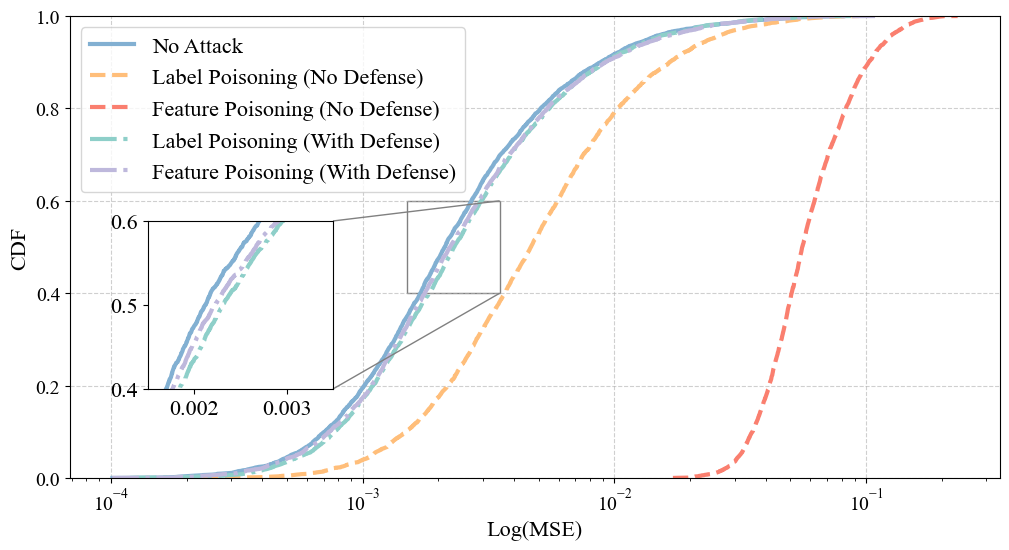

In [11]:
# 绘图设置
fig, ax = plt.subplots(figsize=(12, 6))

plt.xscale('log')

ax.plot(x1, y1, label='No Attack', color='#82B0D2', linewidth=3)
ax.plot(x2, y2, label='Label Poisoning (No Defense)', color='#ffbe7a', linewidth=3, linestyle='--')
ax.plot(x3, y3, label='Feature Poisoning (No Defense)', color='#fa7f6f', linewidth=3, linestyle='--')
ax.plot(x4, y4, label='Label Poisoning (With Defense)', color='#8ecfc9', linewidth=3, linestyle='-.')
ax.plot(x5, y5, label='Feature Poisoning (With Defense)', color='#beb8dc', linewidth=3, linestyle='-.')
ax.set_ylim(0, 1)

ax.xaxis.set_tick_params(labelsize=14)  # 仅x轴
ax.yaxis.set_tick_params(labelsize=14)  # 仅y轴

ax_zoom = inset_axes(ax, width="22%", height="40%", bbox_to_anchor=(-0.35, -0.15, 0.7, 0.7), bbox_transform=ax.figure.transFigure)  # 设置放大图位置和大小
ax_zoom.plot(x1, y1, label='No Attack', color='#82B0D2', linewidth=3)
ax_zoom.plot(x2, y2, label='Label Poisoning (No Defense)', color='#ffbe7a', linewidth=3, linestyle='--')
ax_zoom.plot(x3, y3, label='Feature Poisoning (No Defense)', color='#fa7f6f', linewidth=3, linestyle='--')
ax_zoom.plot(x4, y4, label='Label Poisoning (With Defense)', color='#8ecfc9', linewidth=3, linestyle='-.')
ax_zoom.plot(x5, y5, label='Feature Poisoning (With Defense)', color='#beb8dc', linewidth=3, linestyle='-.')

ax_zoom.set_xlim(0.0015, 0.0035)
ax_zoom.set_ylim(0.4, 0.6)

ax_zoom.xaxis.set_tick_params(labelsize=16)  # 仅x轴
ax_zoom.yaxis.set_tick_params(labelsize=16)  # 仅y轴

# 在主图中标记放大区域（可选）
mark_inset(ax, ax_zoom, loc1=1, loc2=4, fc="none", ec="gray", lw=1)

# 添加样式
# plt.title('Comparison of Global Model MSE Distribution: Normal, Attacked, and Defended Scenarios', fontsize=16)
ax.set_xlabel('Log(MSE)', fontsize=16)
ax.set_ylabel('CDF', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=16)

# plt.tight_layout()

# 显示图像
plt.show()

fig.savefig(f"cdf.pdf", format="pdf", dpi=300, bbox_inches='tight')